# Week 10: Model Validation & Hyperparameter Tuning

**Goal:** Apply stratified k-fold cross-validation to all models built so far.  Perform hyperparameter tuning with GridSearch/RandomizedSearch.  Build the master model comparison table.

**Deliverable:** `minilearn/validation.py` (StratifiedKFold + GridSearchCV) + this notebook.

---
## Checklist
- [ ] `StratifiedKFold` in MiniLearn
- [ ] `cross_val_score` helper
- [ ] `GridSearchCV` in MiniLearn (or wrap sklearn's)
- [ ] CV evaluation for LR, NB, KNN, SVM, DecisionTree, RandomForest
- [ ] Master comparison table: Accuracy, Macro-F1, AUC, training time, best params

In [1]:
import os
import sys
import copy
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

from minilearn.validation import StratifiedKFold, cross_val_score
from minilearn.validation import GridSearchCV as MiniGridSearch
from minilearn.classifiers import (LogisticRegression, GaussianNaiveBayes,
                                   KNearestNeighbors, DecisionTree, LinearSVM)
from minilearn.metrics import accuracy, f1_score

from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

OUTPUT_DIR = 'C:\\Users\\Grana\\Documents\\GitHub\\Project_CSE432_MG\\Project_CSE432-532\\SER_Project\\output'
EMOTION_MAP = {1:'neutral',2:'calm',3:'happy',4:'sad',5:'angry',6:'fearful',7:'disgust',8:'surprised'}

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

X_train = np.load(os.path.join(OUTPUT_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(OUTPUT_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(OUTPUT_DIR, 'y_train.npy')).astype(int)
y_test  = np.load(os.path.join(OUTPUT_DIR, 'y_test.npy')).astype(int)

print(f'X_train {X_train.shape}  X_test {X_test.shape}')

# OVR wrapper (same as Week 8) so LinearSVM works with cross_val_score
class OVRLinearSVM:
    def __init__(self, C=1.0, lr=0.001, n_iter=500):
        self.C = C; self.lr = lr; self.n_iter = n_iter
        self.classifiers_ = []; self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y); self.classifiers_ = []
        for c in self.classes_:
            clf = LinearSVM(C=self.C, lr=self.lr, n_iter=self.n_iter)
            clf.fit(X, np.where(y == c, 1, 0))
            self.classifiers_.append(clf)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        scores = np.column_stack([X @ clf.weights_ + clf.bias_ for clf in self.classifiers_])
        return self.classes_[np.argmax(scores, axis=1)]

    def score(self, X, y):
        return np.mean(self.predict(X) == np.asarray(y))

X_train (1956, 112)  X_test (496, 112)


## 1. Cross-Validation for All Models

In [2]:
# Models to evaluate — mix of MiniLearn and sklearn, all share .fit()/.score()
# MiniLearn DT uses exhaustive split search; cap at depth=4 for tractable CV.
cv_models = [
    ('MiniLearn LR',           LogisticRegression(lr=0.1, n_iter=500)),
    ('MiniLearn GNB',          GaussianNaiveBayes()),
    ('MiniLearn KNN (k=5)',    KNearestNeighbors(k=5)),
    ('MiniLearn DT (d=4)',     DecisionTree(max_depth=4)),
    ('MiniLearn SVM (OVR)',    OVRLinearSVM(C=1.0, lr=0.001, n_iter=500)),
    ('sklearn  LR',            SklearnLR(max_iter=1000, solver='lbfgs')),
    ('sklearn  GNB',           GaussianNB()),
    ('sklearn  KNN (k=5)',     KNeighborsClassifier(n_neighbors=5)),
    ('sklearn  DT (d=4)',      DecisionTreeClassifier(max_depth=4, random_state=42)),
    ('sklearn  SVC (RBF)',     SVC(kernel='rbf', gamma='scale')),
    ('sklearn  RF  (n=100)',   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('sklearn  AdaBoost',      AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                                   n_estimators=100, random_state=42)),
]

cv_results = {}
print(f"{'Model':<28} {'CV Acc Mean':>12} {'± Std':>8}  {'Time (s)':>9}")
print('-' * 62)

for name, clf in cv_models:
    t0     = time.time()
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    elapsed = time.time() - t0
    cv_results[name] = {'mean': scores.mean(), 'std': scores.std(),
                        'scores': scores, 'time': elapsed}
    print(f'{name:<28} {scores.mean():>12.4f} {scores.std():>8.4f}  {elapsed:>9.1f}s')

Model                         CV Acc Mean    ± Std   Time (s)
--------------------------------------------------------------
MiniLearn LR                       0.6160   0.0094        2.5s
MiniLearn GNB                      0.3640   0.0225        0.0s
MiniLearn KNN (k=5)                0.4975   0.0317        0.1s
MiniLearn DT (d=4)                 0.3666   0.0229      225.6s
MiniLearn SVM (OVR)                0.5843   0.0217        2.8s
sklearn  LR                        0.6411   0.0144        0.7s
sklearn  GNB                       0.3640   0.0225        0.0s
sklearn  KNN (k=5)                 0.4975   0.0317        3.1s
sklearn  DT (d=4)                  0.3656   0.0227        0.6s
sklearn  SVC (RBF)                 0.6416   0.0175        1.6s
sklearn  RF  (n=100)               0.5869   0.0151        1.9s
sklearn  AdaBoost                  0.3748   0.0216       14.4s


## 2. Hyperparameter Tuning

In [3]:
# ── MiniLearn GridSearch: KNN — sweep k ─────────────────────────────────────
print('=== MiniLearn GridSearch: KNN ===')
gs_knn = MiniGridSearch(
    KNearestNeighbors(),
    param_grid={'k': [1, 3, 5, 7, 11]},
    cv=5, scoring='accuracy'
)
gs_knn.fit(X_train, y_train)
print(f'  Best params : {gs_knn.best_params_}')
print(f'  Best CV acc : {gs_knn.best_score_:.4f}')
print(gs_knn.results_dataframe().to_string(index=False))

# ── MiniLearn GridSearch: LogisticRegression — sweep lr × n_iter ─────────────
print('\n=== MiniLearn GridSearch: LogisticRegression ===')
gs_lr = MiniGridSearch(
    LogisticRegression(),
    param_grid={'lr': [0.01, 0.1, 0.5], 'n_iter': [200, 500]},
    cv=5, scoring='accuracy'
)
gs_lr.fit(X_train, y_train)
print(f'  Best params : {gs_lr.best_params_}')
print(f'  Best CV acc : {gs_lr.best_score_:.4f}')
print(gs_lr.results_dataframe().to_string(index=False))

# ── sklearn GridSearch: SVC (RBF) — C × gamma ────────────────────────────────
print('\n=== sklearn GridSearch: SVC (RBF) ===')
from sklearn.model_selection import GridSearchCV as SkGridSearch
gs_svc = SkGridSearch(
    SVC(kernel='rbf'), cv=5, scoring='accuracy', n_jobs=-1,
    param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto', 0.001, 0.01]}
)
gs_svc.fit(X_train, y_train)
print(f'  Best params : {gs_svc.best_params_}')
print(f'  Best CV acc : {gs_svc.best_score_:.4f}')

# Store best params for the master table
best_params_summary = {
    'MiniLearn KNN':    gs_knn.best_params_,
    'MiniLearn LR':     gs_lr.best_params_,
    'sklearn SVC (RBF)': gs_svc.best_params_,
}
print('\nBest parameters summary:')
for model, params in best_params_summary.items():
    print(f'  {model:<22}: {params}')

=== MiniLearn GridSearch: KNN ===
  Best params : {'k': 1}
  Best CV acc : 0.5721
 k  mean_score  std_score
 1    0.572130   0.021929
 3    0.510269   0.024649
 5    0.497507   0.031740
 7    0.492386   0.040053
11    0.483153   0.017065

=== MiniLearn GridSearch: LogisticRegression ===
  Best params : {'lr': 0.5, 'n_iter': 500}
  Best CV acc : 0.6421
  lr  n_iter  mean_score  std_score
0.50     500    0.642125   0.008123
0.50     200    0.631379   0.012552
0.10     500    0.616049   0.009447
0.10     200    0.588969   0.022617
0.01     500    0.532750   0.027329
0.01     200    0.458090   0.016635

=== sklearn GridSearch: SVC (RBF) ===
  Best params : {'C': 10, 'gamma': 'scale'}
  Best CV acc : 0.7014

Best parameters summary:
  MiniLearn KNN         : {'k': 1}
  MiniLearn LR          : {'lr': 0.5, 'n_iter': 500}
  sklearn SVC (RBF)     : {'C': 10, 'gamma': 'scale'}


## 3. Master Model Comparison Table

=== Master Model Comparison Table ===
                       CV Acc   ± Std  Test Acc  Macro-F1  Train Time(s)                Best Params
Model                                                                                              
sklearn  LR            0.6411  0.0144    0.6734    0.6693           0.18       lbfgs, max_iter=1000
MiniLearn LR (tuned)   0.6160  0.0094    0.6452    0.6392           0.65         lr=0.5, n_iter=500
MiniLearn SVM (OVR)    0.5843  0.0217    0.6069    0.5940           0.58              C=1, lr=0.001
sklearn  AdaBoost      0.3748  0.0216    0.3871    0.3584           3.65  n_estimators=100, depth=1
MiniLearn DT (d=4)     0.3666  0.0229    0.3690    0.3032          60.32                max_depth=4
sklearn  DT (d=4)      0.3656  0.0227    0.3690    0.3032           0.14                max_depth=4
MiniLearn GNB          0.3640  0.0225    0.3750    0.3490           0.00                    default
sklearn  GNB           0.3640  0.0225    0.3750    0.3490     

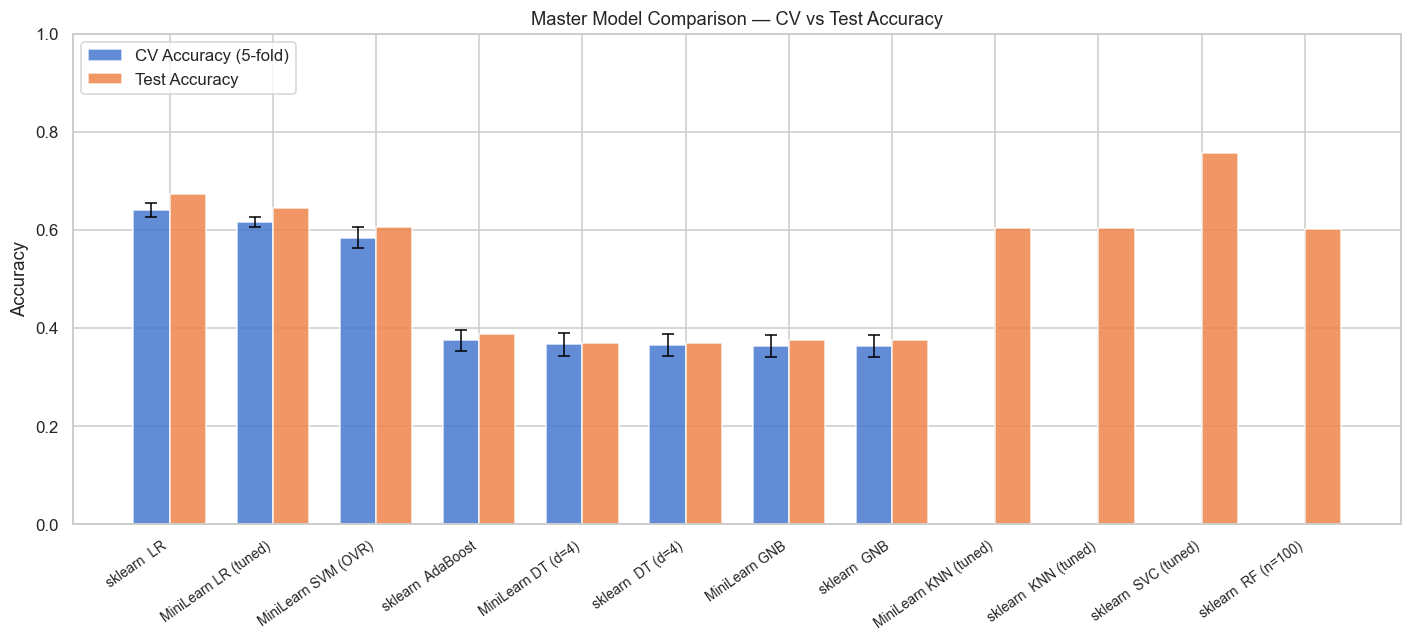

In [4]:
# Refit each model on full X_train with best params, evaluate on X_test
best_knn_k   = gs_knn.best_params_['k']
best_lr_lr   = gs_lr.best_params_['lr']
best_lr_iter = gs_lr.best_params_['n_iter']
best_svc_C   = gs_svc.best_params_['C']
best_svc_g   = gs_svc.best_params_['gamma']

final_models = [
    ('MiniLearn LR (tuned)',
     LogisticRegression(lr=best_lr_lr, n_iter=best_lr_iter),
     f"lr={best_lr_lr}, n_iter={best_lr_iter}"),

    ('MiniLearn GNB',
     GaussianNaiveBayes(),
     'default'),

    ('MiniLearn KNN (tuned)',
     KNearestNeighbors(k=best_knn_k),
     f"k={best_knn_k}"),

    ('MiniLearn DT (d=4)',
     DecisionTree(max_depth=4),
     'max_depth=4'),

    ('MiniLearn SVM (OVR)',
     OVRLinearSVM(C=1.0, lr=0.001, n_iter=500),
     'C=1, lr=0.001'),

    ('sklearn  LR',
     SklearnLR(max_iter=1000, solver='lbfgs'),
     'lbfgs, max_iter=1000'),

    ('sklearn  GNB',
     GaussianNB(),
     'default'),

    ('sklearn  KNN (tuned)',
     KNeighborsClassifier(n_neighbors=best_knn_k),
     f"k={best_knn_k}"),

    ('sklearn  DT (d=4)',
     DecisionTreeClassifier(max_depth=4, random_state=42),
     'max_depth=4'),

    ('sklearn  SVC (tuned)',
     SVC(kernel='rbf', C=best_svc_C, gamma=best_svc_g),
     f"C={best_svc_C}, gamma={best_svc_g}"),

    ('sklearn  RF (n=100)',
     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
     'n_estimators=100'),

    ('sklearn  AdaBoost',
     AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                        n_estimators=100, random_state=42),
     'n_estimators=100, depth=1'),
]

rows = []
for name, clf, params_str in final_models:
    t0 = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred   = clf.predict(X_test) if hasattr(clf, 'predict') else None
    test_acc = accuracy(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    cv_mean  = cv_results.get(name.split('(tuned)')[0].strip(),
               cv_results.get(name, {})).get('mean', float('nan'))
    cv_std   = cv_results.get(name.split('(tuned)')[0].strip(),
               cv_results.get(name, {})).get('std',  float('nan'))

    rows.append({
        'Model':        name,
        'CV Acc':       round(cv_mean, 4),
        '± Std':        round(cv_std,  4),
        'Test Acc':     round(test_acc, 4),
        'Macro-F1':     round(macro_f1, 4),
        'Train Time(s)': round(train_time, 2),
        'Best Params':  params_str,
    })

master = (pd.DataFrame(rows)
            .set_index('Model')
            .sort_values('CV Acc', ascending=False))

print('=== Master Model Comparison Table ===')
print(master.to_string())

# ── Bar chart: CV Acc vs Test Acc ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
x      = np.arange(len(master))
width  = 0.35
ax.bar(x - width/2, master['CV Acc'],   width, label='CV Accuracy (5-fold)', alpha=0.85)
ax.bar(x + width/2, master['Test Acc'], width, label='Test Accuracy',         alpha=0.85)
ax.errorbar(x - width/2, master['CV Acc'], yerr=master['± Std'],
            fmt='none', color='black', capsize=4, linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(master.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1)
ax.set_title('Master Model Comparison — CV vs Test Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'master_comparison.png'), bbox_inches='tight')
plt.show()

## 4. Discussion

*Address:*
- *Which model achieves the best generalization performance?*
- *How does CV accuracy compare to the held-out test accuracy from earlier weeks?*
- *What do the hyperparameter searches reveal about each model's sensitivity?*